## Testing how fast_hdbscan does without the probabaility rank matrix using ARI

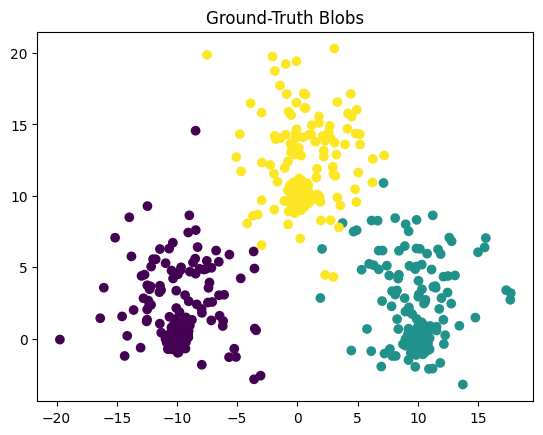

In [93]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt

centers = [[-10.0, 0.0], [-10.0, 3.0], [10.0, 0.0], [10.0, 3.0], [0.0, 10.0], [0.0, 13.0]]
clusters_std = [0.5, 3.0, 0.5, 3.0, 0.5, 3.0]

n_per_comp = [100, 100, 100, 100, 100, 100]

X, raw_labels = make_blobs(
    n_samples = n_per_comp,
    centers = centers,
    cluster_std = clusters_std,
    random_state = 42
)

true_labels = raw_labels // 2

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show()

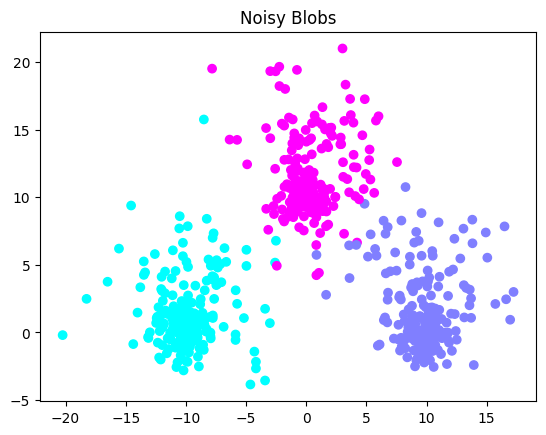

In [94]:
from fast_hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
import numpy as np

std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="cool")
plt.title("Noisy Blobs")
plt.show()

In [95]:
k = 5 

clusterer = HDBSCAN(
    min_samples=k, 
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(X_obs)

ari = adjusted_rand_score(labels_true=true_labels, labels_pred=pred_labels)
print("ARI (uncertainty-aware):", ari)

ARI (uncertainty-aware): 0.5660863038914506
